# Text Toxicity Moderation

**Assignment #4 — Text Toxicity Moderation**

A complete, beginner-friendly but production-shaped ML project that trains a
model to detect toxic (abusive/insulting/harassing) text comments, evaluates
it, wraps it in a reusable prediction function, and ships a Gradio demo app
so a trainer/reviewer can test it in the browser without writing any code.

**Pipeline:** raw text → cleaning → TF-IDF features → Logistic Regression /
Linear SVM classifier → evaluation → `predict_toxicity()` → Gradio app.


## 1. Problem Statement

**What is text toxicity moderation?**

Text toxicity moderation is the task of automatically detecting whether a
piece of user-generated text (a comment, chat message, review, support
ticket, forum post, etc.) is **toxic** — i.e. rude, disrespectful, insulting,
threatening, or otherwise likely to make someone leave a conversation or
platform — versus **non-toxic** (civil, on-topic, respectful).

**Why is it useful?**

- **Platform safety** — social networks, forums, comment sections, and chat
  apps need to protect users from harassment and abuse at a scale no human
  moderation team can handle manually.
- **Brand and legal risk** — unmoderated toxic content damages trust and can
  create legal/compliance exposure for the platform owner.
- **Faster moderation workflows** — an automated first-pass filter lets human
  moderators focus their limited time on borderline/ambiguous cases instead
  of re-reading every single message.
- **Better user experience** — proactively hiding, flagging, or warning about
  toxic content (rather than reacting after complaints) keeps communities
  healthier and more inclusive.
- **Customer support triage** — the same technique can flag abusive support
  tickets/live-chat messages so agents (and their managers) can prioritize
  and get support when dealing with hostile customers.

In this notebook we build a lightweight, fast, and explainable **binary
text classifier** (toxic vs. non-toxic) using classic NLP + machine learning
— no GPU or deep learning required — that is realistic to deploy for a
first-pass moderation filter.


## 2. Dataset

**Preferred real-world dataset:** the
[Jigsaw Toxic Comment Classification Challenge](https://www.kaggle.com/competitions/jigsaw-toxic-comment-classification-challenge/data)
dataset (Wikipedia talk-page comments, human-labelled for
`toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, `identity_hate`), or
the related
[Civil Comments](https://www.kaggle.com/competitions/jigsaw-unintended-bias-in-toxicity-classification/data)
dataset. Both are also mirrored on the
[Hugging Face Hub](https://huggingface.co/datasets/google/civil_comments).

**This notebook is dataset-agnostic** — the loading cell below:

1. First looks for a real dataset at `data/raw/train.csv` (Jigsaw format).
2. If not found, falls back to the small **offline sample dataset**
   (`data/sample_toxicity_data.csv`, 100 hand-written rows, 50 toxic /
   50 non-toxic) that ships with this repo, so the notebook always runs
   top-to-bottom with zero setup and no API keys.

See `data/README.md` for full download instructions for the real dataset.

Either way, the data is normalized to two columns:

| column         | meaning                                |
|-----------------|------------------------------------------|
| `comment_text`  | raw text of the comment                  |
| `toxic`         | binary label — `1` = toxic, `0` = clean  |


In [1]:
import os
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42
print("Libraries loaded.")

Libraries loaded.


In [2]:
RAW_PATH = os.path.join("data", "raw", "train.csv")
SAMPLE_PATH = os.path.join("data", "sample_toxicity_data.csv")

TOXIC_LABEL_COLS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

if os.path.exists(RAW_PATH):
    print(f"Loading real dataset from {RAW_PATH} ...")
    df = pd.read_csv(RAW_PATH)
    text_col = "comment_text" if "comment_text" in df.columns else df.columns[0]
    df = df.rename(columns={text_col: "comment_text"})
    present = [c for c in TOXIC_LABEL_COLS if c in df.columns]
    if present:
        df["toxic"] = (df[present].sum(axis=1) > 0).astype(int)
    df = df[["comment_text", "toxic"]]
    DATA_SOURCE = "Jigsaw (real dataset)"
else:
    print(f"Real dataset not found at {RAW_PATH}.")
    print(f"Falling back to offline sample dataset: {SAMPLE_PATH}")
    df = pd.read_csv(SAMPLE_PATH)
    DATA_SOURCE = "Offline sample dataset (100 rows)"

print(f"Data source : {DATA_SOURCE}")
print(f"Shape       : {df.shape}")
df.head()

Real dataset not found at data\raw\train.csv.
Falling back to offline sample dataset: data\sample_toxicity_data.csv
Data source : Offline sample dataset (100 rows)
Shape       : (100, 2)


,comment_text,toxic
0,"You're a coward and a liar, disgusting behavio...",1
1,"Get a life, you sad, pathetic troll.",1
2,"I think the design looks clean and modern, nic...",0
3,Only a complete moron would post something thi...,1
4,"This recipe turned out delicious, thanks for p...",0


**Example toxic vs. non-toxic rows from the dataset:**

In [3]:
print("TOXIC examples:")
for t in df[df["toxic"] == 1]["comment_text"].head(3):
    print(" -", t)

print("\nNON-TOXIC examples:")
for t in df[df["toxic"] == 0]["comment_text"].head(3):
    print(" -", t)

TOXIC examples:
 - You're a coward and a liar, disgusting behavior honestly.
 - Get a life, you sad, pathetic troll.
 - Only a complete moron would post something this stupid.

NON-TOXIC examples:
 - I think the design looks clean and modern, nice work.
 - This recipe turned out delicious, thanks for posting it.
 - Thank you so much for explaining this, it really helped me understand.


**Data cleaning steps applied:**

1. Drop rows with missing/empty `comment_text`.
2. Drop exact duplicate comments.
3. Ensure `toxic` is a clean binary integer column.

(Deeper text-level cleaning — lowercasing, URL/special-character removal —
is done in the *Preprocessing* section below, as it's needed for both
training and inference.)


In [4]:
before = len(df)
df["comment_text"] = df["comment_text"].astype(str)
df = df[df["comment_text"].str.strip() != ""]
df = df.dropna(subset=["comment_text", "toxic"])
df = df.drop_duplicates(subset=["comment_text"])
df["toxic"] = df["toxic"].astype(int)
after = len(df)

print(f"Rows before cleaning : {before}")
print(f"Rows after cleaning  : {after}")
print(f"Rows removed         : {before - after}")

Rows before cleaning : 100
Rows after cleaning  : 100
Rows removed         : 0


## 3. Exploratory Data Analysis (EDA)

Label distribution (0 = non-toxic, 1 = toxic):
toxic
0    50
1    50
Name: count, dtype: int64

Toxic ratio: 50.00%


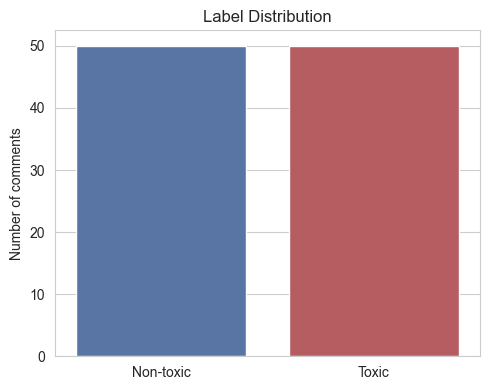

In [5]:
label_counts = df["toxic"].value_counts().sort_index()
print("Label distribution (0 = non-toxic, 1 = toxic):")
print(label_counts)
print(f"\nToxic ratio: {label_counts.get(1, 0) / len(df):.2%}")

plt.figure(figsize=(5, 4))
sns.barplot(x=label_counts.index.map({0: "Non-toxic", 1: "Toxic"}),
            y=label_counts.values, hue=label_counts.index.map({0: "Non-toxic", 1: "Toxic"}),
            palette=["#4C72B0", "#C44E52"], legend=False)
plt.title("Label Distribution")
plt.ylabel("Number of comments")
plt.xlabel("")
plt.tight_layout()
plt.show()

toxic                      0          1
text_length count  50.000000  50.000000
            mean   58.200000  56.720000
            std     5.488392   7.499769
            min    45.000000  36.000000
            25%    55.000000  51.000000
            50%    58.000000  57.000000
            75%    61.000000  62.750000
            max    70.000000  70.000000
word_count  count  50.000000  50.000000
            mean    9.940000   9.980000
            std     1.150155   1.789881
            min     8.000000   7.000000
            25%     9.000000   9.000000
            50%    10.000000   9.500000
            75%    11.000000  11.000000
            max    13.000000  14.000000

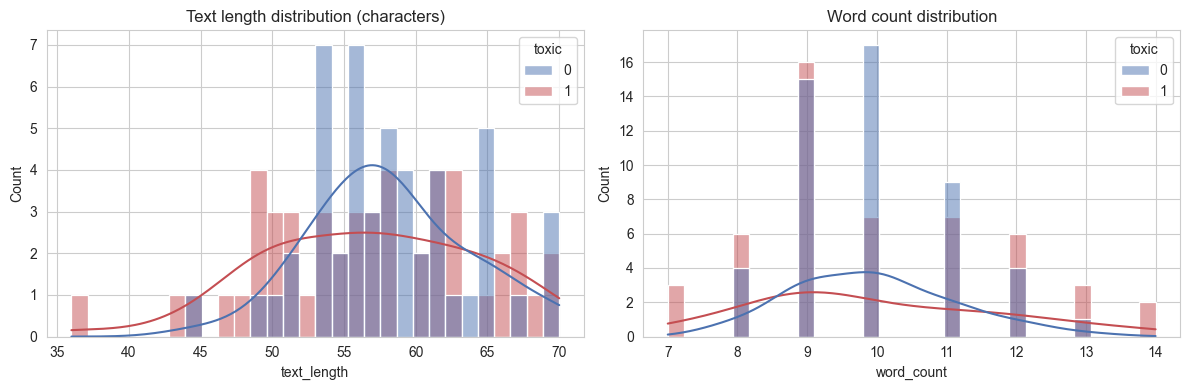

In [6]:
df["text_length"] = df["comment_text"].str.len()
df["word_count"] = df["comment_text"].str.split().apply(len)

print(df.groupby("toxic")[["text_length", "word_count"]].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="text_length", hue="toxic", bins=30, kde=True,
             palette=["#4C72B0", "#C44E52"], ax=axes[0])
axes[0].set_title("Text length distribution (characters)")

sns.histplot(data=df, x="word_count", hue="toxic", bins=30, kde=True,
             palette=["#4C72B0", "#C44E52"], ax=axes[1])
axes[1].set_title("Word count distribution")
plt.tight_layout()
plt.show()

In [7]:
print("Random sample rows:")
df.sample(min(8, len(df)), random_state=RANDOM_STATE)[["comment_text", "toxic", "word_count"]]

Random sample rows:


,comment_text,toxic,word_count
83,Please review the attached document and share ...,0,9
53,"I disagree with your point, but I appreciate t...",0,11
70,"You are such an idiot, how do you not understa...",1,13
45,Please let me know if you need any more inform...,0,13
44,You are worthless and everyone here despises you.,1,8
39,"Go away, you pathetic little troll, nobody wan...",1,10
22,"You absolute clown, learn to code before embar...",1,9
80,"I'm not sure I agree, could you elaborate a bi...",0,11


## 4. Preprocessing

Text cleaning steps:

- Lowercase everything.
- Remove URLs.
- Remove special characters / punctuation / digits (keep plain words).
- Collapse extra whitespace.
- Handle missing values (already dropped above).
- Train/test split (stratified, so both splits keep the same toxic ratio).


In [8]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
SPECIAL_CHARS_RE = re.compile(r"[^a-z\s]")
MULTI_SPACE_RE = re.compile(r"\s+")


def clean_text(text: str) -> str:
    """Lowercase, strip URLs/special characters, and normalize whitespace."""
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = SPECIAL_CHARS_RE.sub(" ", text)
    text = MULTI_SPACE_RE.sub(" ", text).strip()
    return text


df["clean_text"] = df["comment_text"].apply(clean_text)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

df[["comment_text", "clean_text", "toxic"]].head()

,comment_text,clean_text,toxic
0,"You're a coward and a liar, disgusting behavio...",you re a coward and a liar disgusting behavior...,1
1,"Get a life, you sad, pathetic troll.",get a life you sad pathetic troll,1
2,"I think the design looks clean and modern, nic...",i think the design looks clean and modern nice...,0
3,Only a complete moron would post something thi...,only a complete moron would post something thi...,1
4,"This recipe turned out delicious, thanks for p...",this recipe turned out delicious thanks for po...,0


In [9]:
X = df["clean_text"]
y = df["toxic"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")
print("Train label balance:\n", y_train.value_counts(normalize=True))
print("\nTest label balance:\n", y_test.value_counts(normalize=True))

Train size: 80  |  Test size: 20
Train label balance:
 toxic
0    0.5
1    0.5
Name: proportion, dtype: float64

Test label balance:
 toxic
1    0.5
0    0.5
Name: proportion, dtype: float64


## 5. Model Training

We train two lightweight, fast, and interpretable models on **TF-IDF**
features (no GPU / deep learning needed for a solid first-pass moderation
filter):

- **Option A — TF-IDF + Logistic Regression** (gives calibrated probability
  scores out of the box — great for a confidence score in the UI).
- **Option B — TF-IDF + Linear SVM** (often slightly higher accuracy on
  short text, wrapped in `CalibratedClassifierCV` so it can also output
  probabilities).

We compare both on the test set and keep the better one as the final model.


In [10]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True,
)

logreg_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=1, sublinear_tf=True)),
    ("clf", CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", random_state=RANDOM_STATE), cv=3
    )),
])

logreg_pipeline.fit(X_train, y_train)
svm_pipeline.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


## 6. Evaluation

In [11]:
def evaluate_model(name, pipeline, X_test, y_test):
    preds = pipeline.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-score : {f1:.3f}")
    print()
    return {"name": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "preds": preds}


results_logreg = evaluate_model("TF-IDF + Logistic Regression", logreg_pipeline, X_test, y_test)
results_svm = evaluate_model("TF-IDF + Linear SVM", svm_pipeline, X_test, y_test)

# Pick the better model by F1-score
best = results_logreg if results_logreg["f1"] >= results_svm["f1"] else results_svm
model = logreg_pipeline if best["name"].endswith("Logistic Regression") else svm_pipeline
best_name = best["name"]
print(f"Selected best model: {best_name}")

--- TF-IDF + Logistic Regression ---
Accuracy : 0.900
Precision: 0.900
Recall   : 0.900
F1-score : 0.900

--- TF-IDF + Linear SVM ---
Accuracy : 0.900
Precision: 0.900
Recall   : 0.900
F1-score : 0.900

Selected best model: TF-IDF + Logistic Regression


              precision    recall  f1-score   support

   Non-toxic       0.90      0.90      0.90        10
       Toxic       0.90      0.90      0.90        10

    accuracy                           0.90        20
   macro avg       0.90      0.90      0.90        20
weighted avg       0.90      0.90      0.90        20



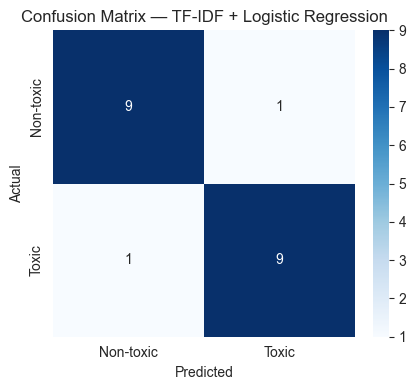

In [12]:
print(classification_report(y_test, best["preds"], target_names=["Non-toxic", "Toxic"]))

cm = confusion_matrix(y_test, best["preds"])
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-toxic", "Toxic"], yticklabels=["Non-toxic", "Toxic"])
plt.title(f"Confusion Matrix — {best['name']}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [13]:
results_df = X_test.to_frame()
results_df["actual"] = y_test.values
results_df["predicted"] = best["preds"]

false_positives = results_df[(results_df["actual"] == 0) & (results_df["predicted"] == 1)]
false_negatives = results_df[(results_df["actual"] == 1) & (results_df["predicted"] == 0)]

print(f"False positives (flagged toxic but actually clean): {len(false_positives)}")
print(false_positives["clean_text"].head(5).to_list())

print(f"\nFalse negatives (missed toxic content): {len(false_negatives)}")
print(false_negatives["clean_text"].head(5).to_list())

False positives (flagged toxic but actually clean): 1
['congratulations on your promotion you truly earned it']

False negatives (missed toxic content): 1
['this is the dumbest article i have ever read the writer is a moron']


## 7. Prediction Function

`predict_toxicity(text)` wraps the trained pipeline (cleaning + TF-IDF +
classifier) into a single reusable function that a downstream app (e.g. the
Gradio demo) can call directly.


In [14]:
def predict_toxicity(text: str, model=model, threshold: float = 0.5) -> dict:
    """
    Predict whether a piece of text is toxic.

    Parameters
    ----------
    text : str
        Raw input text (comment, message, review, etc.).
    model : sklearn Pipeline
        Trained TF-IDF + classifier pipeline (defaults to the best model above).
    threshold : float
        Probability threshold above which text is classified as toxic.

    Returns
    -------
    dict with keys:
        label        : "Toxic" or "Non-toxic"
        confidence   : float in [0, 1], model's confidence in the predicted label
        toxic_score  : float in [0, 1], raw probability of being toxic
        explanation  : short human-readable explanation of the moderation decision
    """
    if not text or not str(text).strip():
        return {
            "label": "Non-toxic",
            "confidence": 1.0,
            "toxic_score": 0.0,
            "explanation": "Empty input — nothing to moderate.",
        }

    cleaned = clean_text(text)
    proba = model.predict_proba([cleaned])[0]
    toxic_score = float(proba[1])
    is_toxic = toxic_score >= threshold
    label = "Toxic" if is_toxic else "Non-toxic"
    confidence = toxic_score if is_toxic else 1 - toxic_score

    if is_toxic and toxic_score >= 0.85:
        explanation = (
            "This message contains strong indicators of insulting/abusive "
            "language and should likely be blocked or sent for review."
        )
    elif is_toxic:
        explanation = (
            "This message shows moderate signs of toxic language "
            "(e.g. insults or hostile tone) and should be flagged for review."
        )
    else:
        explanation = (
            "No strong indicators of toxic language were detected; "
            "this message looks safe to publish."
        )

    return {
        "label": label,
        "confidence": round(confidence, 4),
        "toxic_score": round(toxic_score, 4),
        "explanation": explanation,
    }


# Quick smoke test
for sample in [
    "Thank you for your help, this was very useful!",
    "You are such an idiot, shut up already.",
    "Can we schedule a call tomorrow to discuss the project?",
]:
    result = predict_toxicity(sample)
    print(f"Text: {sample!r}\n  -> {result}\n")

Text: 'Thank you for your help, this was very useful!'
  -> {'label': 'Non-toxic', 'confidence': 0.5586, 'toxic_score': 0.4414, 'explanation': 'No strong indicators of toxic language were detected; this message looks safe to publish.'}

Text: 'You are such an idiot, shut up already.'
  -> {'label': 'Toxic', 'confidence': 0.6839, 'toxic_score': 0.6839, 'explanation': 'This message shows moderate signs of toxic language (e.g. insults or hostile tone) and should be flagged for review.'}

Text: 'Can we schedule a call tomorrow to discuss the project?'
  -> {'label': 'Non-toxic', 'confidence': 0.6108, 'toxic_score': 0.3892, 'explanation': 'No strong indicators of toxic language were detected; this message looks safe to publish.'}



### Save the trained model

We export the full pipeline (TF-IDF vectorizer + classifier bundled
together) with `joblib`, so it can be loaded directly by `app.py` for the
Gradio demo — no retraining needed.


In [15]:
import os
os.makedirs("models", exist_ok=True)

MODEL_PATH = os.path.join("models", "toxicity_model.joblib")
joblib.dump(model, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

# Also save a small metadata file describing which model + metrics were used
metadata = {
    "model_name": best["name"],
    "accuracy": best["accuracy"],
    "precision": best["precision"],
    "recall": best["recall"],
    "f1": best["f1"],
    "data_source": DATA_SOURCE,
    "n_train": len(X_train),
    "n_test": len(X_test),
}
joblib.dump(metadata, os.path.join("models", "metadata.joblib"))
print(metadata)

Model saved to models\toxicity_model.joblib
{'model_name': 'TF-IDF + Logistic Regression', 'accuracy': 0.9, 'precision': 0.9, 'recall': 0.9, 'f1': 0.9, 'data_source': 'Offline sample dataset (100 rows)', 'n_train': 80, 'n_test': 20}


## 8. Multilingual Discussion

**Can this model work for multiple languages?**

Not directly. The model in this notebook is trained on **TF-IDF features
of English text**, so its vocabulary (and therefore its predictions) is
English-only. Feeding it Spanish, Hindi, or Arabic text will produce mostly
meaningless/unreliable predictions because those words never appeared in
training.

**Limitations of this approach for multilingual moderation:**

- TF-IDF is a bag-of-words method: it has zero notion of meaning outside the
  exact tokens (and n-grams) seen during training. It cannot generalize
  across languages or even catch heavy misspellings/leetspeak reliably.
- Toxicity is culturally and linguistically context-dependent — slang,
  sarcasm, and what counts as "insulting" differs a lot by language/region,
  so a single English-trained model cannot be assumed to transfer.
- Code-mixed text (e.g. Hindi-English "Hinglish") is especially hard for
  simple bag-of-words models.

**Two practical paths to multilingual support:**

1. **Translation approach (quick, cheaper):**
   Translate incoming text to English (e.g. via a translation API or an
   open-source MT model) and then run it through this existing English
   toxicity classifier. Pros: reuses this model as-is, fast to implement.
   Cons: translation quality varies, subtle toxic phrasing/idioms/sarcasm
   can be lost or altered in translation, and it adds latency + an external
   dependency.

2. **Multilingual transformer approach (better long-term):**
   Fine-tune a multilingual pretrained transformer such as
   `xlm-roberta-base`, `bert-base-multilingual-cased`, or
   `distilbert-base-multilingual-cased` directly on toxic/non-toxic labelled
   text **in each target language** (or on a multilingual toxicity dataset
   such as the Jigsaw Multilingual Toxic Comment Classification dataset,
   which covers English, Spanish, French, Italian, Portuguese, Russian, and
   Turkish). This captures language-specific nuance without a separate
   translation step, at the cost of needing a GPU for training/inference and
   more labelled data.

**Data requirement per language:**

- A workable baseline typically needs on the order of **several thousand
  labelled examples per language**, ideally with a reasonable mix of toxic
  and non-toxic examples (not just a handful of hand-picked cases) — real
  production systems (e.g. Jigsaw's multilingual dataset, Perspective API)
  use hundreds of thousands of labelled comments per language for the best
  results.
- Fine-tuning a multilingual transformer benefits from **cross-lingual
  transfer** — training on several languages together often improves
  performance on lower-resource languages that have less labelled data of
  their own, because the shared multilingual embedding space transfers some
  general "toxicity" signal across languages.


## 9. Real-world Data Sources

Where to find more toxic / non-toxic examples to expand and improve this
model beyond the public research datasets:

- **Public datasets** — Jigsaw Toxic Comment Classification, Jigsaw
  Unintended Bias (Civil Comments), Jigsaw Multilingual Toxic Comment
  Classification, HateXplain, OLID/OffensEval, Hugging Face Hub toxicity
  datasets.
- **Support tickets / help-desk transcripts** — customer messages
  (especially escalations) sometimes contain hostile or abusive language
  toward agents; useful for a support-specific toxicity filter.
- **Chat logs** — in-app chat, live chat, or community Discord/Slack logs
  (with consent) reflect real toxic behavior patterns specific to your
  product's audience.
- **Social media comments** — public comment sections (Twitter/X, YouTube,
  Reddit, Instagram) via their official APIs, respecting each platform's
  terms of service and rate limits.
- **Community forums** — product forums, subreddits, or discussion boards
  related to your domain often have moderator-flagged/removed posts that
  make excellent labelled toxic examples.
- **Customer reviews** — app store reviews, product reviews, and complaint
  text sometimes contain abusive language directed at the business or other
  users.
- **Manually labelled internal data** — the highest-quality, most relevant
  data is usually your own product's user-generated content, hand-labelled
  by a trained internal moderation/annotation team (or a vendor such as
  Appen/Scale AI) using clear labelling guidelines and multiple annotators
  per example for quality control.

### Privacy, consent, anonymization, and bias risks

- **Privacy & consent** — only collect and use user-generated content in
  ways covered by your platform's terms of service / privacy policy. Get
  explicit consent where required (e.g. for internal chat logs), and follow
  applicable regulations (GDPR, CCPA, etc.) for storing and processing
  personal data.
- **Anonymization** — strip or hash personally identifiable information
  (usernames, emails, phone numbers, addresses) from training data before
  storage/sharing, and restrict access to raw labelled data to the people
  who actually need it.
- **Annotator well-being** — reviewing toxic content repeatedly is
  psychologically taxing for human labellers; rotate annotators, limit
  session lengths, and provide support resources.
- **Bias risks** — toxicity datasets are known to pick up **spurious
  correlations with identity terms** (e.g. comments mentioning certain
  religions, ethnicities, or sexual orientations getting flagged as toxic
  more often than similar comments without those terms, simply because of
  how the training data was collected/labelled). This can cause the model
  to unfairly over-flag legitimate speech from or about certain groups.
  Mitigations include: auditing the model with subgroup-specific evaluation
  sets (the Jigsaw Unintended Bias dataset was built exactly for this),
  balancing training data across identity mentions, and having a human
  review step before any irreversible action (e.g. permanent bans) is taken
  based on model output.
- **Labeling consistency** — use clear, written labelling guidelines and
  measure inter-annotator agreement; inconsistent labels directly become
  inconsistent (and sometimes biased) model behavior.


## 10. Gradio Demo

A ready-to-run Gradio app (`app.py`, in the project root) loads the saved
`models/toxicity_model.joblib` pipeline and exposes a simple browser UI:

- A text box to enter a message.
- An **Analyze** button.
- The predicted label (Toxic / Non-toxic), a confidence score, and a
  friendly moderation-advice message.

Run it locally with:

```bash
pip install -r requirements.txt
python app.py
```

This opens a local URL (e.g. `http://127.0.0.1:7860`) — open it in a
browser to test the model interactively. See `app.py` for the full
implementation, and the `huggingface_space/` folder for a version ready to
deploy to Hugging Face Spaces.


## 11. Hosting Instructions — Deploying to Hugging Face Spaces

The `huggingface_space/` folder in this repo is a self-contained,
ready-to-upload package (`app.py`, `requirements.txt`, `README.md`, and the
trained `models/toxicity_model.joblib`). To deploy it:

1. Create a free account at [huggingface.co](https://huggingface.co).
2. Click **New Space** → choose a name (e.g. `text-toxicity-moderation`) →
   select **Gradio** as the Space SDK → choose **Public** visibility →
   click **Create Space**.
3. Upload the contents of `huggingface_space/` to the new Space's repo
   (either via the web "Add file" UI, or with git):
   ```bash
   git clone https://huggingface.co/spaces/<your-username>/text-toxicity-moderation
   cp -r huggingface_space/* text-toxicity-moderation/
   cd text-toxicity-moderation
   git add .
   git commit -m "Add toxicity moderation Gradio app"
   git push
   ```
4. Hugging Face automatically builds the Space using `requirements.txt` and
   launches `app.py`. Within a minute or two you'll get a public URL like:
   `https://huggingface.co/spaces/<your-username>/text-toxicity-moderation`
5. Share that URL with your trainer/reviewer — they can type text and get
   a live toxicity prediction with **zero installation**.


## 12. Final Submission Section

What to submit for this assignment:

1. **Notebook** — `text_toxicity_moderation.ipynb` (this file), fully run
   top-to-bottom with outputs saved.
2. **GitHub repo link** —
   `https://github.com/sapradeep123/TextToxicityModeration`
   (push all project files: notebook, `app.py`, `requirements.txt`,
   `README.md`, `data/`, `models/`, `huggingface_space/`).
3. **Hugging Face Spaces live demo link** — after following Section 11,
   paste your Space URL here, e.g.:
   `https://huggingface.co/spaces/<your-username>/text-toxicity-moderation`
4. **README.md** — project overview, setup steps, and results summary
   (already included at the repo root).

### Project summary

This notebook builds an end-to-end text toxicity moderation pipeline:
data loading & cleaning → EDA → preprocessing → TF-IDF + Logistic
Regression / Linear SVM training → evaluation (accuracy, precision, recall,
F1, confusion matrix, error analysis) → a reusable `predict_toxicity()`
function → a Gradio demo app → deployment instructions for Hugging Face
Spaces. It also discusses multilingual extension paths and responsible,
privacy-aware ways to source more real-world moderation data.
